In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('iris.csv')

In [8]:
df.shape

(150, 5)

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [9]:
x = df.iloc[:,:-1].values
y = df.iloc[:,4].values


In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x_train)
x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
classifier =KNeighborsClassifier(n_neighbors = 5)
classifier.fit(x_train,y_train)

KNeighborsClassifier()

In [16]:
y_predict = classifier.predict(x_test)

In [17]:
print(y_predict)

['setosa' 'virginica' 'virginica' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'setosa' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'virginica' 'setosa' 'virginica' 'virginica' 'virginica' 'virginica'
 'setosa' 'versicolor' 'setosa' 'virginica' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'versicolor' 'setosa' 'setosa']


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.88      0.88         8
   virginica       0.92      0.92      0.92        12

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

 
[[10  0  0]
 [ 0  7  1]
 [ 0  1 11]]


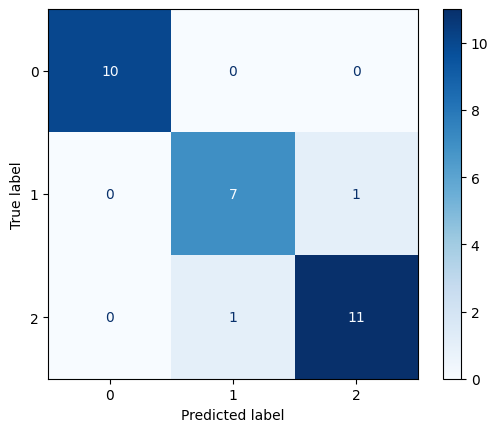

In [27]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print(classification_report(y_test,y_predict))
print(" ")
print(confusion_matrix(y_test,y_predict))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_predict)).plot(cmap="Blues")
plt.show()